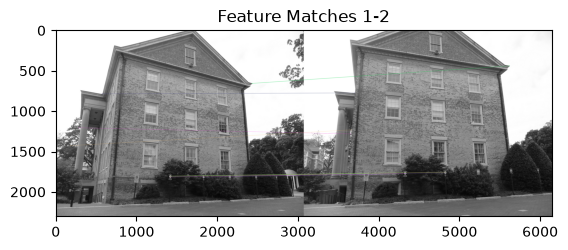

Saved matches_1-2.jpg


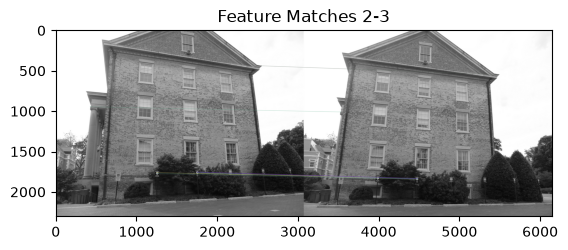

Saved matches_2-3.jpg


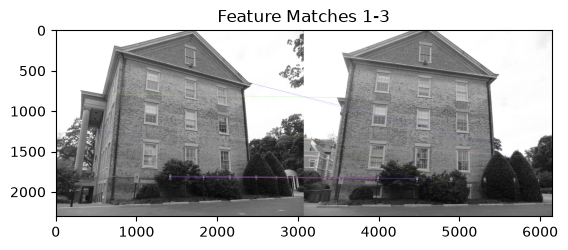

Saved matches_1-3.jpg


In [6]:
# --- 3D Reconstruction Demo Notebook ---
# Rabeea Iman's PMW-day1 Challenge

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ Step 1: Load images
img1 = cv2.imread(r"D:\3D Reconstruction\NoteBOOOOK\image1.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(r"D:\3D Reconstruction\NoteBOOOOK\image2.jpg", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread(r"D:\3D Reconstruction\NoteBOOOOK\image3.jpg", cv2.IMREAD_GRAYSCALE)


# ✅ Step 2: ORB feature detection
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)
kp3, des3 = orb.detectAndCompute(img3, None)

# ✅ Step 3: Match features pair by pair
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

pairs = [
    (img1, kp1, des1, img2, kp2, des2, "1-2"),
    (img2, kp2, des2, img3, kp3, des3, "2-3"),
    (img1, kp1, des1, img3, kp3, des3, "1-3")
]

for (A, kpA, desA, B, kpB, desB, label) in pairs:
    matches = bf.match(desA, desB)
    matches = sorted(matches, key=lambda x: x.distance)
    
    match_img = cv2.drawMatches(A, kpA, B, kpB, matches[:20], None, flags=2)
    plt.imshow(match_img)
    plt.title(f"Feature Matches {label}")
    plt.show()
    
    cv2.imwrite(f"matches_{label}.jpg", match_img)
    print(f"Saved matches_{label}.jpg")
